# Task 2 – Low-Compute ECG Artefact Identification

For this task, I will implement a **feature-based, unsupervised method for identifying artefact-corrupted ECG segments**. The aim is to use simple signal properties and threshold-based rules instead of a trained machine-learning classifier, to make the approach suitable for low-power wearable devices.

## Common ECG Artefacts

The main artefacts considered in this implementation are:

1. **Loose lead / electrode disconnection**  
   A loose or disconnected electrode can result in a nearly flat signal, large baseline excursions, and intermittent signal loss.

2. **50/60 Hz power-line interference**  
   It may be caused by electromagnetic interference, or disconnection in the driven-right-leg circuitry.

3. **Baseline wander**  
   Commonly caused by respiration, body movement, or changes in electrode-skin impedance.

4. **Muscle tremor / EMG artefact**  
   Skeletal-muscle activity introduces irregular high-frequency components into the ECG.

5. **Neuromodulation artefact**  
   Implanted electrical stimulation devices, such as neurostimulators, can introduce periodic pulses into the recorded ECG.

6. **Arterial pulse artefact**  
   Mechanical pulsation can affect an electrode positioned close to a strongly pulsating artery producing repetitive disturbances.

## ECG Frequency Content

The frequency content required from an ECG depends on the intended application. Diagnostic ECG systems generally require a wider bandwidth than monitoring systems. In this implementation, the useful ECG band is considered to extend approximately from **0.05 Hz to 100 Hz**, while particular sub-bands are analysed to identify different types of artefacts.

## Proposed Approach

The ECG signal will be divided into short segments and a small number of computationally inexpensive features will be calculated for each segment. These features include:

- Signal RMS / energy
- Low-frequency energy for baseline wander
- 50/60 Hz energy for power-line interference
- High-frequency energy for muscle artefact
- Simple QRS/R-peak consistency measurements

The resulting feature values will be compared against predefined or experimentally derived thresholds to classify each ECG segment as either:

**VALID** or **CORRUPTED**


In [71]:
!pip install wfdb matplotlib scipy numpy


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Sampling frequency: 360 Hz
Number of samples: 21600
Duration: 60.00 s


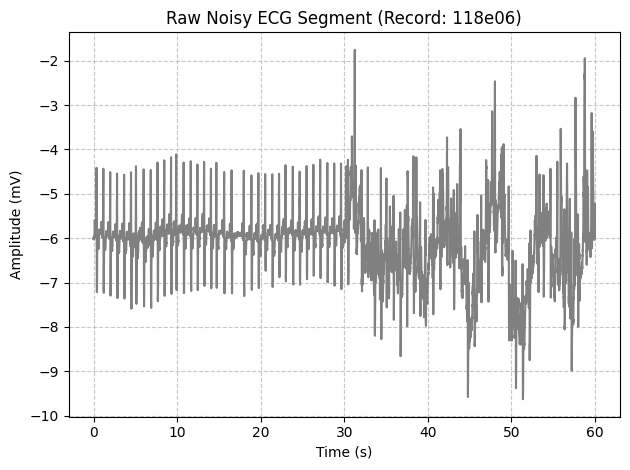

In [72]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, sosfiltfilt

# Load the data from PhysioNet
# 118e06 has 6dB noise
# Sample rate is 360Hz according to the dataset
# Since the noise is occuring after 5min according to the dataset
# Taking from 4.5min to 5.5min time period into consideration
record = wfdb.rdrecord('118e06', pn_dir='nstdb/1.0.0', sampfrom=97200, sampto=118800)

# Extract the signal and the sampling frequency
ecg_signal = record.p_signal[:, 0]  # First ECG lead/channel
fs = record.fs                      # Sampling frequency (360 Hz)
time = np.arange(len(ecg_signal)) / fs # time array in seconds

print(f"Sampling frequency: {fs} Hz")
print(f"Number of samples: {len(ecg_signal)}")
print(f"Duration: {len(ecg_signal)/fs:.2f} s")

fig, ax = plt.subplots()

ax.plot(time, ecg_signal, color='gray');
ax.set_title(f'Raw Noisy ECG Segment (Record: {record.record_name})')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (mV)')
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [73]:
# Implement functions to measure properties of the ECG segment

# Bandpass Filter
def bandpass_filter(signal, lowcut, highcut, fs, order=2):
    sos = butter(order, [lowcut, highcut], btype='bandpass', fs=fs, output='sos')
    return sosfiltfilt(sos, signal)

# Signal features related to frequencies
def signalFeatures(ecg):
    x = np.asarray(ecg, dtype=float)

    # Remove DC
    x = x - np.mean(x)

    # 1. Signal RMS
    rms = np.sqrt(np.mean(x ** 2))

    # 2. Check if there is no energy in the ECG band, if there is not it should be an electrode is disconnected
    ecg_band = bandpass_filter(ecg, 0.5, 100, fs)
    ecg_energy = np.mean(ecg_band ** 2)

    # 3. Check for too much baseline wander (Could be an electrode is connected)
    baseline_band = bandpass_filter(ecg, 0.05, 0.5, fs)
    baseline_energy = np.mean(baseline_band ** 2)
    baseline_ratio = baseline_energy / (ecg_energy + 1e-12)

    # 4. Check for power line noise (50Hz and 60Hz)
    powerline50_band = bandpass_filter(ecg, 48, 52, fs)
    powerline60_band = bandpass_filter(ecg, 58, 62, fs)
    powerline_energy = max(np.mean(powerline50_band ** 2), np.mean(powerline60_band ** 2))
    powerline_ratio = powerline_energy / (ecg_energy + 1e-12)

    # 5. Check for muscle tremor
    # ECG      : 0.5Hz - 30Hz (mostly)
    # HF noise : 30Hz - 45Hz
    highfreq_band = bandpass_filter(ecg, 0.5, 30, fs)
    lowfreq_band = bandpass_filter(ecg, 30, 45, fs)

    lowfreq_energy = np.mean(lowfreq_band ** 2)
    highfreq_energy = np.mean(highfreq_band ** 2)

    highfreq_ratio = highfreq_energy / (lowfreq_energy + 1e-12)

    return rms, ecg_energy, baseline_ratio, powerline_ratio, highfreq_ratio

In [81]:
# Get 5s ECG segments 
segment_duration = 5
segment_samples = int(segment_duration * fs)

# 4.5 min = 270 seconds
start_time = 270

# Calculate number of 5s segments betwenn 4.5min to 5.5min
num_segments = len(ecg_signal) // segment_samples

print(
    "Segment | Time (s)     |  RMS     | "
    "Baseline Ratio | Powerline Ratio | HF Ratio"
)

print("-" * 100)

for i in range(num_segments):

    start = i * segment_samples
    end = start + segment_samples

    ecg_segment = ecg_signal[start:end]

    rms, ecg_energy, baseline_ratio, powerline_ratio, highfreq_ratio = signalFeatures(ecg_segment)

    start_time = start_time + i * segment_duration
    end_time = start_time + segment_duration

    print(
        f"{i + 1:7d} | "
        f"{start_time:4.0f} -{end_time:4.0f} s | "
        f"{rms:8.4f} | "
        f"{baseline_ratio:14.4f} | "
        f"{powerline_ratio:15.4f} | "
        f"{highfreq_ratio:8.4f}"
    )

Segment | Time (s)     |  RMS     | Baseline Ratio | Powerline Ratio | HF Ratio
----------------------------------------------------------------------------------------------------
      1 |  270 - 275 s |   0.4113 |         0.0122 |          0.0004 |  67.4270
      2 |  275 - 280 s |   0.4784 |         0.0258 |          0.0004 |  60.9347
      3 |  285 - 290 s |   0.3984 |         0.0207 |          0.0002 |  65.0220
      4 |  300 - 305 s |   0.3560 |         0.0075 |          0.0001 |  65.7665
      5 |  320 - 325 s |   0.3449 |         0.1235 |          0.0003 |  60.5274
      6 |  345 - 350 s |   0.3640 |         0.0062 |          0.0002 |  62.1026
      7 |  375 - 380 s |   0.8428 |         0.4149 |          0.0003 | 114.8290
      8 |  410 - 415 s |   0.6816 |         0.5039 |          0.0003 | 108.6504
      9 |  450 - 455 s |   0.8501 |         1.0294 |          0.0003 | 109.0476
     10 |  495 - 500 s |   1.1292 |         2.0530 |          0.0003 | 130.5403
     11 |  545 - 55

In [ ]:
# Implement a function to calculate the overall score for the ECG segment


In [76]:
# Need to calculate thresholds according to the dataset


In [77]:
# Depending on the score label the segment


In [78]:
# R peak detection algorithm

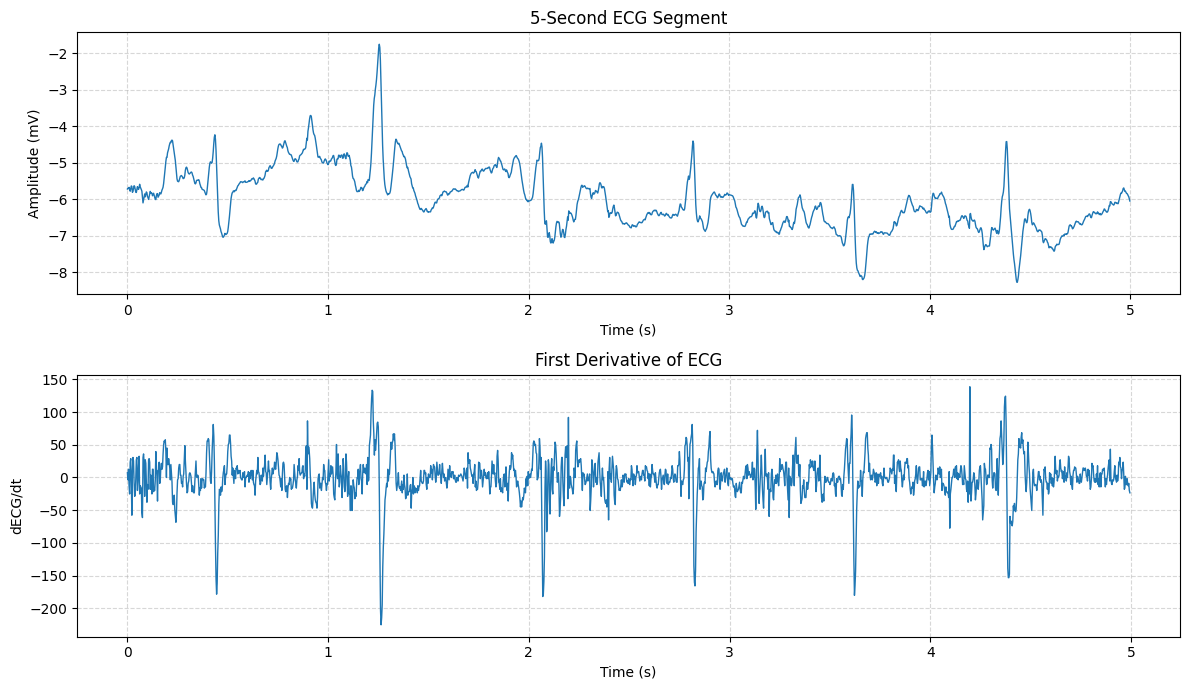

In [79]:
# ============================================================
# Select first 5-second segment
# ============================================================

segment_duration = 5  # seconds
start = int((300-270) * fs)
N = int(segment_duration * fs)
end = start + N

ecg_segment = ecg_signal[start:end]

time = np.arange(N) / fs

# ============================================================
# First derivative
# ============================================================

# dECG/dt
derivative = np.diff(ecg_segment) * fs

# Time vector for derivative
time_derivative = time[:-1]

# ============================================================
# Plot ECG and first derivative
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Original ECG
axes[0].plot(
    time,
    ecg_segment,
    linewidth=1
)

axes[0].set_title("5-Second ECG Segment")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude (mV)")
axes[0].grid(True, linestyle="--", alpha=0.5)

# First derivative
axes[1].plot(
    time_derivative,
    derivative,
    linewidth=1
)

axes[1].set_title("First Derivative of ECG")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("dECG/dt")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Computational complexity compared to a simple ML classifier

# Artifacts that can be missed in this approach
